# Benchmarking of lava flow models -- Realistic test case -- Mauna Loa 2022 eruption
This notebook compares several forward models of lava flow emplacement using the 2022 eruption of Mauna Loa as a test case. The input to all the models include the topography of Mauna Loa, the location of the main vent (fissure 3), and other parameters required for each model, such as volume, duration, or effusion rate. All of the other required input parameters have been pre-stored in the input files for each model.  


In [1]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess
import os
import utm
import xarray as xr
import rasterio as rio
from pyproj import Transformer
import sys
import glob
import geopandas as gpd
import pyproj
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

<h3>Common Parameters</h3>

Here we provide the parameters that are shared among all models: topography=, vent location, and eruption volume/duration/flux, depending on the model's assumptions. 

The notebook accept a DEM in either lat/lon geotiff format or UTM asc format.

The vent location can be in either UTM or lat/lon

In [2]:
os.chdir("/home/jovyan/Lava_Benchmark")

latitude  = 19.5131

longitude = -155.5308
# Total volume in m^3 from eruption
volume = 2e8

# IMEX and Lava2d are depth-averaged time-dependent models, and thus require an approximate run time.
# Below, we assign a reasonable yet arbitrary time (3 hour) for the flow to run (in seconds)
# Please change it at your leisure
run_time = 3600

# Please enter 1, 2, or 4 (original resolution, half, quarter respectively)
downscale = 2

# Full path to your DEM file (.tif/.tiff or .asc/.ascii)
dem = "./DEMs_Lava_Benchmark/MaunaLoa.tif"

# UTM zone — only needed if dem is an ASC file without a .prj
# Enter zone number and hemisphere, e.g. "5N" for Hawaii, "33S" for New Zealand
utm_zone = "5N"

run_in_background = False

gdf = gpd.read_file("DEMs_Lava_Benchmark/flowoutline.shp")

viz_only_flag = False


<h4> The following cell re-formats the DEMs to ensure we provide each model with the appropriate format </h4

In [3]:
from pathlib import Path
from pyproj import Transformer, CRS
import pyproj
from pyproj.database import query_utm_crs_info

def get_utm_epsg(zone: int, hemisphere: str, datum: str = "WGS 84") -> int:
    """
    Finds the EPSG code for a given UTM zone using pyproj.
    hemisphere: 'N' for North, 'S' for South
    datum: Defaults to 'WGS 84'
    """
    # Query the database for the specific UTM zone criteria
    crs_list = query_utm_crs_info(
        datum_name=datum,
        area_of_interest=None # Optional geographic boundary constraint
    )
    
    # Filter the list by zone and hemisphere
    for crs in crs_list:
        # e.g., "WGS 84 / UTM zone 32N"
        if f"zone {zone}{hemisphere.upper()}" in crs.name:
            return int(crs.code)
            
    raise ValueError(f"No EPSG code found for UTM zone {zone}{hemisphere}")

dem_path = Path(dem)
base_dir  = dem_path.parent          # e.g. .../DEMs_Lava_Benchmark
name      = dem_path.stem            # e.g. MaunaLoa
file_extension = dem_path.suffix.lower()

raster = rxr.open_rasterio(dem)
raster = raster.sel({"band": 1})
output_num = str(int(run_time / 100))
out = output_num.zfill(4)

zone_num = int(utm_zone[:-1])
hemisphere = utm_zone[-1].upper()
utm_crs = pyproj.CRS(f"+proj=utm +zone={zone_num} +{'north' if hemisphere == 'N' else 'south'}")
print ('utm_crs=', utm_crs)

type_flag = 0  # 0 = source is ASC, 1 = source is TIFF
if file_extension in [".geotiff", ".tiff", ".tif"]:
    type_flag = 1
    dem_asc_name  = str(base_dir / f"{name}.asc")
    dem_tiff_name = str(dem)
    raster = raster.rio.reproject(
    raster.rio.crs,
    resolution=(20, 20))
    if not Path(dem_asc_name).exists():
        raster.rio.to_raster(f"./DEMs_Lava_Benchmark/{name}.asc")
elif file_extension in [".asc", ".ascii"]:
    type_flag = 0
    dem_asc_name  = str(dem)   # already an ASC
    prj_name = str(base_dir / f"{name}.prj")
    dem_tiff_name = str(base_dir / f"{name}.tif")
    if not Path(prj_name).exists():
        if utm_zone is None:
            raise ValueError("ASC file has no .prj — please set 'utm_zone' in Cell 3 (e.g. '5N')")
        asc_crs = utm_crs
        with open(prj_name, 'w') as prj:
            prj.write(asc_crs.to_wkt())
    if not Path(dem_tiff_name).exists():
        epsg = get_utm_epsg(zone=int(utm_zone[:-1]), hemisphere=utm_zone[-1])
        print(epsg)
        raster = raster.rio.write_crs(f"epsg:{epsg}")
        raster.rio.to_raster(dem_tiff_name)
else:
    raise ValueError(f"Unsupported DEM format: '{file_extension}'. Use .tif, .tiff, .asc, or .ascii")

print(f"Name: {name}")
print(f"ASC:  {dem_asc_name}")
print(f"TIFF: {dem_tiff_name}")


utm_crs= +proj=utm +zone=5 +north +type=crs
Name: MaunaLoa
ASC:  DEMs_Lava_Benchmark/MaunaLoa.asc
TIFF: ./DEMs_Lava_Benchmark/MaunaLoa.tif


<h2> Before starting the computation, we confirm the location of the vent is as expected </h2>

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'DEMs_Lava_Benchmark/MaunaLoa.asc'}, xlabel='Easting', ylabel='Northing'>)

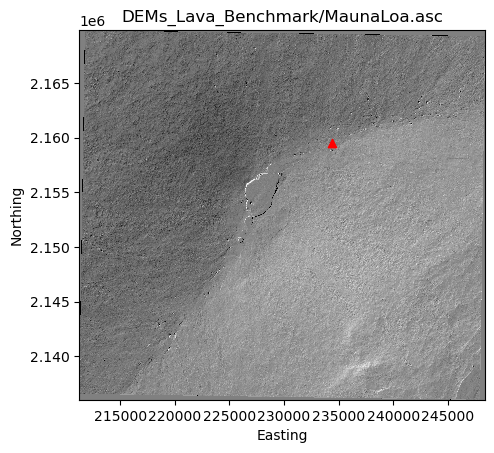

In [4]:
os.chdir('/home/jovyan/Lava_Benchmark/')

zone_num   = int(utm_zone[:-1])
hemisphere = utm_zone[-1].upper()
utm_crs = pyproj.CRS.from_proj4(f"+proj=utm +zone={zone_num} +{'north' if hemisphere == 'N' else 'south'}")

utm_to_latlon = pyproj.Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)
latlon_to_utm = pyproj.Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
rstr = rio.open(dem_asc_name)
bounds = rstr.bounds
easting, northing = latlon_to_utm.transform(longitude,latitude)
xll, yll = int(bounds.left), int(bounds.bottom)

print(f"UTM ({easting}, {northing}) -> lat/lon ({latitude:.4f}, {longitude:.4f})")

r = rio.open(dem)
array = rxr.open_rasterio(dem_asc_name)
res = array.rio.resolution()
vent_easting, vent_northing = easting, northing
coordinates = np.array([easting, northing])
victor.plot_dem(dem_asc_name, coordinates)


<h4> here we are defining utilities that will help convert between the UTM zone of the test case to global lat/lon coordinates. Make sure to update the zone to the appropriate one  </h4> 

### Now, we can run everything. Press run on every cell until the next text box.

Keep in mind, the time dependent models can take a long time, so sit back and relax, though keep an eye out for your results. Each model will also display its individual result before the final comparison.

### Molasses: Additional Notes

Molasses input parameters are stored in `custom_molasses.conf` in the `Molasses` folder. The most impactful change would be that of changing the minimum and maximum residual, as the cellular automata structure will cause a much larger or smaller area to be impacted. As a stochastic model, no physical parameters are used.

In [ ]:
os.chdir("/home/jovyan/Lava_Benchmark/Molasses")
f = open("custom_molasses.conf", "r+")
conf = f.readlines()
conf[2] = "MIN_RESIDUAL = .5\n"
conf[3] = "MAX_RESIDUAL = 9\n"
conf[4] = f"MIN_TOTAL_VOLUME = {str(volume)}\n"
conf[5] = f"MAX_TOTAL_VOLUME = {str(volume)}\n"
conf[6] = f"MIN_PULSE_VOLUME = {float(volume)/1000}\n"
conf[7] = f"MAX_PULSE_VOLUME = {float(volume)/1000}\n"
conf[10] = f"""DEM_FILE = ../{dem_asc_name}\n"""
f.seek(0)
f.writelines(conf)
f.truncate()
f.close()

f = open("events.in", "w")
f.write(f"{easting},{northing}")
f.close()

if viz_only_flag != True:
    subprocess.run("./molasses_2022 custom_molasses.conf", shell=True,stderr=subprocess.DEVNULL)
    
victor.convert_molasses(f"molasses_{name}", resolution=30)
os.remove(f"molasses_{name}.asc.aux.xml")
os.remove(f"molasses_{name}.prj")

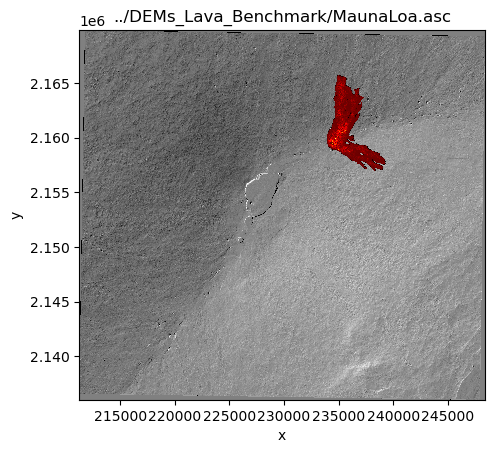

In [7]:
victor.plot_flow(f"../{dem_asc_name}", f"./molasses_{name}.asc", zoom=False, title='Molasses', colorbar=True)


### MrLavaLoba: Additional Notes

MrLavaLoba input parameters are stored in `input_data.py` in the `mr_lava_loba` folder. The most impactful changes would be those such as the thickening parameter, lobe exponent, or max slope probability. Other parameters not mentioned will also affect the creation and placement of lobes. As a stochastic model, no physical parameters are specified by the user.

In [8]:
os.chdir('/home/jovyan/Lava_Benchmark/mr_lava_loba/')
subprocess.run("cp mr_lava_loba_maunaloa.inp mr_lava_loba.inp", shell=True)
g = open("mr_lava_loba.inp", "r+")
inp = g.readlines()
inp[1] = f' RUN_NAME="{name}",\n'
inp[2] = f' SOURCE="../DEMs_Lava_Benchmark/{name}.asc"\n'
inp[13] = f" X_VENT= {easting},\n"
inp[14] = f" Y_VENT= {northing},\n"
inp[26] = f" TOTAL_VOLUME={volume},\n"
g.seek(0)
g.writelines(inp)
g.truncate()
g.close()

if viz_only_flag != True:
    subprocess.run("mr_lava_loba", shell=True)
subprocess.run("cp mr_lava_loba.inp mr_lava_loba_maunaloa.inp", shell=True)



 Mr Lava Loba by M.de' Michieli Vitturi and S.Tarquini

 Run name: MaunaLoa                                          
 x_vent    234392.00000000000     
 y_vent    2159562.0000000000     
 Average Lobe thickness =   0.31250000000000000       m
 Searching for masking thresholds
 Run name MaunaLoa_001
 

 Reading DEM file:../DEMs_Lava_Benchmark/MaunaLoa.asc
 Extent of the DEM
 xW,xE,yS,yN   211246.47709999999        248380.69979999957        2136026.7384000001        2169845.7610573457     

 Cropping of original DEM
 xW,xE,yS,yN   229392.00000000000        239392.00000000000        2157562.0000000000        2169562.0000000000     
 iW,iE,jS,jN        1823        2829        2164        3370

 lx,ly    229385.49955560299        2157560.6053437265     
 Saving asc file: MaunaLoa_001_cropped_DEM.asc
 Saving completed
 End pre-processing

 Computing flow
 Percent Complete:   1.56% ERROR : the lava has reached the DEM margin
 Please increase east_to_vent
 Percent Complete:   3.12% ERROR : t

CompletedProcess(args='mv mr_lava_loba.inp mr_lava_loba_maunaloa.inp', returncode=0)

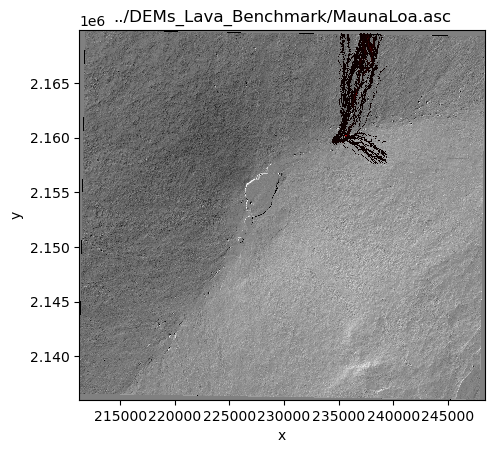

In [9]:
os.chdir('/home/jovyan/Lava_Benchmark/mr_lava_loba/')
mll_outputs = sorted(glob.glob(f'{name}*thickness_full.asc'))
mll_out = mll_outputs[-1]
victor.plot_flow(f"../{dem_asc_name}",mll_out,zoom=False, title='Mr_Lava_Loba', colorbar=True)

### IMEX_Lava: Additional Notes

IMEX_Lava input parameters are stored in `IMEX_LavaFlow.inp` in the `IMEX` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `TEMPERATURE_PARAMETERS`, `RHEOLOGY_PARAMETERS`, `GAS_TRANSPORT_PARAMETERS`, and `LIQUID_TRANSPPORT_PARAMETERS` namelists as needed. All other sections are carefully prepared based in your initial basic inputs, so ignore all other sections.

In [10]:
import multiprocessing
def IMEX_background():
    p = subprocess.Popen(['./IMEX_LavaFlow'], stdin=subprocess.PIPE, shell=True)
    p.communicate(input=b'\n')
    subprocess.run("cp IMEX_LavaFlow.inp IMEX_LavaFlow_maunaloa.inp", shell=True)

In [ ]:
os.chdir("/home/jovyan/Lava_Benchmark/IMEX_LavaFlow")
subprocess.run("cp IMEX_LavaFlow_maunaloa.inp IMEX_LavaFlow.inp", shell=True)
subprocess.run(f"cp ../DEMs_Lava_Benchmark/{name}.asc .", shell=True)

h = open("IMEX_LavaFlow.inp", "r+")
inp = h.readlines()
inp[1]  = f' RUN_NAME="{name}"\n'
inp[4]  = f" T_END=  {run_time},\n"
inp[5]  = f" DT_OUTPUT=  1000,\n"
inp[13] = f' TOPOGRAPHY_FILE="{name}.asc"                  ,\n'
inp[14] = f" X0= {int(xll)+res[0]}     ,\n"
inp[15] = f" Y0= {int(yll)+res[0]}     ,\n"
inp[16] = f" COMP_CELLS_X=  {int(len(array.x)/downscale)-5},\n"
inp[17] = f" COMP_CELLS_Y=  {int(len(array.y)/downscale)-5},\n"
inp[18] = f" CELL_SIZE = {res[0]*downscale}D0 ,\n"
inp[103] = f"  X_SOURCE=  {int(vent_easting)}.0D0 ,\n"
inp[104] = f"  Y_SOURCE=  {int(vent_northing)}.0D0 ,\n"
inp[105] = f"  R_SOURCE=  {res[0]}D0     ,\n"
inp[106] = f" VEL_SOURCE= {float(volume)/(res[0]**2*np.pi*run_time)} \n"
h.seek(0)
h.writelines(inp)
h.truncate()
h.close()

if viz_only_flag != True:
    if run_in_background:
        p = multiprocessing.Process(target=IMEX_background)
        p.start()
    else:
        import subprocess
    
        p = subprocess.Popen(
            './IMEX_LavaFlow',
            shell=True,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1
        )
    
        p.stdin.write('\n')
        p.stdin.close()
    
        for i, line in enumerate(p.stdout, 1):
            if i % 100 == 0:
                print(f"\r{i}: {line.strip()}", end="")
        p.wait()
        subprocess.run("cp IMEX_LavaFlow.inp IMEX_LavaFlow_maunaloa.inp", shell=True)

os.chdir("/home/jovyan/Lava_Benchmark")


In [ ]:
os.chdir("/home/jovyan/Lava_Benchmark/IMEX_LavaFlow")
victor.plot_flow(f"../{dem_asc_name}", f"{name}_max.asc", zoom=False, title='IMEX_LavaFlow', colorbar=True)
os.chdir("/home/jovyan/Lava_Benchmark")


### LAVA2D: Additional Notes

LAVA2D input parameters are stored in `input.py` in the `lava2d` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `set_vent_props`, `set_lava_props`, `set_rheo`, `set_ambient`, and `set_numeric` sections as needed. All other sections are carefully prepared based in your initial basic inputs, so please leave them as is.

In [11]:
os.chdir("/home/jovyan/Lava_Benchmark/Lava2d")


# TIFF bounds are already in lat/lon
rstr_tiff = rio.open(f"../{dem_tiff_name}")

left, bottom, right, top = rstr_tiff.bounds
print(left, bottom, right, top)
# Convert UTM vent coords -> lat/lon
src_lon, src_lat = utm_to_latlon.transform(vent_easting, vent_northing)
left, bottom = utm_to_latlon.transform(left, bottom)
right, top = utm_to_latlon.transform(right, top)
max_time_hours = run_time/3600
print('easting northing = ', vent_easting, vent_northing)
print('src= ', src_lon, src_lat)

print(f"res[0] = {res[0]}")
print(f"downscale = {downscale}")
print(f"dx_desired = {res[0]*downscale}")
print(f"DEM size: {len(array.x)} x {len(array.y)} cells")
print(f"After downscale: {int(len(array.x)/downscale)} x {int(len(array.y)/downscale)} cells")

meters_per_degree = 111320  # approximate, good enough for Hawaii
dx_degrees = (res[0] * downscale) / meters_per_degree

l = open("input.py", "r+")
inp = l.readlines()

# Use relative path to avoid string-length limits in lava2d
inp[4]  = f"    path_to_dem_file    = ('../DEMs_Lava_Benchmark/{name}.tif'),\n"
inp[5]  = f"    Lon_SRC             = {src_lon}, # source longitude\n"
inp[6]  = f"    Lat_SRC             = {src_lat}, # source latitude\n"
inp[7]  = f"    Lon_LowerLeft       = {left}, # bounding box: lower-left longitude\n"
inp[8]  = f"    Lat_LowerLeft       = {bottom}, # bounding box: lower-left latitude\n"
inp[9]  = f"    Lon_UpperRight      = {right}, # bounding box: upper-right longitude\n"
inp[10] = f"    Lat_UpperRight      = {top},   # bounding box: upper-right latitude\n"
inp[12] = f"    dx_desired          = {res[0]*downscale},          # meters\n"
inp[70] = f"    max_iter = None, #one of them can be none, so the default value for both is none, if both none run till killed\n"
inp[71] = f"    max_time_hr = {max_time_hours},\n"
inp[72] = f"    out_times = [{max_time_hours/4}, {max_time_hours/2}, {3*max_time_hours/4}],\n"
l.seek(0)
l.writelines(inp)
l.truncate()
l.close()

k = open("./example_vents/vent_01.txt", "r+")
inp = k.readlines()

# if (type_flag == 0):
inp[1] = f'0\t0\t0\t100\t-75\t20\t{volume/(run_time*50)}\n'
inp[2] = f'10000\t0\t0\t100\t-75\t20\t{volume/(run_time*50)}\n'
# else:
#     inp[1] = f'{src_lon}\t{src_lat}\t0\t100\t-75\t20\t{volume/(run_time*50)}\n'
#     inp[2] = f'{src_lon}\t{src_lat}\t10000\t100\t-75\t20\t{volume/(run_time*50)}\n'

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

if viz_only_flag != True:
    p = subprocess.Popen(
        'python input.py',
        shell=True,
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    for i, line in enumerate(p.stdout, 1):
        if i % 100 == 0:
            print(f"\r{i}: {line.strip()}", end="")
    p.wait()
else:
    print("Not running Lava2D")

211246.4771 2136026.7384 248380.6998 2169845.7611
easting northing =  234392 2159562
src=  -155.53081018658628 19.51309350854104
res[0] = 9.955555683646
downscale = 2
dx_desired = 19.911111367292
DEM size: 3730 x 3397 cells
After downscale: 1865 x 1698 cells


KeyboardInterrupt: 

In [12]:
# Re-derive lat/lon bounds from the already-open raster handle
src = utm_to_latlon.transform(vent_easting, vent_northing)
left, bottom, right, top = rstr_tiff.bounds

In [ ]:
data = xr.open_dataset(
    "outputs/MaunaLoa/out.nc",
    group="DATA/PHYSICS",
    decode_coords="all"
)

coord = xr.open_dataset(
    "outputs/MaunaLoa/out.nc",
    group="DATA",
    decode_coords="all"
)
data = data.where(data!=0, np.nan)
transformer2 = Transformer.from_crs("EPSG:4326", utm_crs.to_epsg())
lat = coord.lat[:,0]
lon = coord.lon[0,:]
data['rows'] = lat.values
data['cols'] = lon.values

data = data.rename({"rows": "y", "cols": "x"})
repeated_arr_x = np.repeat(data.y.values[0], len(data.x))
repeated_arr_y = np.repeat(data.x.values[0], len(data.y))

utm1 = transformer2.transform(repeated_arr_x,data.x.values)
utm2 = transformer2.transform(data.y.values,repeated_arr_y)
# print(utm1[0], utm2[1])
data['x'] = utm1[0]
data['y'] = utm2[1]
data = data.transpose("y", "x")
data.lava_thickness_total.rio.to_raster(f"lava2d_{name.lower()}.asc")

In [ ]:
os.chdir("/home/jovyan/Lava_Benchmark/Lava2d")
victor.plot_flow(f"../{dem_asc_name}", f"lava2d_{name.lower()}.asc", title='Lava2D', colorbar=True)
os.chdir("/home/jovyan/Lava_Benchmark")


### Finally, we can take a look at all the models side by side.

In [15]:
os.chdir("/home/jovyan/Lava_Benchmark/")

#Find range of results for each of the models' output

r1 = rxr.open_rasterio(f"Molasses/molasses_{name}.asc",masked=True)
r2 = rxr.open_rasterio(f"mr_lava_loba/{mll_out}",masked=True)
r3 = rxr.open_rasterio(f"IMEX_LavaFlow/{name}_max.asc",masked=True)
r4 = rxr.open_rasterio(f"Lava2d/lava2d_{name.lower()}.asc",masked=True)
r1_min, r1_max = r1.min(), r1.max()
r2_min, r2_max = r2.min(), r2.max()
r3_min, r3_max = r3.min(), r3.max()
r4_min, r4_max = r4.min(), r4.max()

maximum = np.max((r1_max,r2_max,r3_max,r4_max))
idx_max = np.argmax((r1_max,r2_max,r3_max,r4_max))

In [ ]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2, figsize = (9,9))
gdf.plot(ax=ax0)
gdf.plot(ax=ax1)
gdf.plot(ax=ax2)
gdf.plot(ax=ax3)
thickness0 = victor.plot_flow(dem_asc_name, f"Molasses/molasses_{name}.asc", axes=ax0,title='Molasses',minimum=1e-6,scale=maximum)
thickness1 = victor.plot_flow(dem_asc_name, f"mr_lava_loba/{mll_out}", axes=ax1, title='MrLavaLoba',minimum=1e-6, scale=maximum)
thickness2 = victor.plot_flow(dem_asc_name, f"IMEX_LavaFlow/{name}_max.asc", axes=ax2,title='IMEX_LavaFlow', minimum=1e-6, scale=maximum)
thickness3 = victor.plot_flow(dem_asc_name, f"Lava2d/lava2d_{name.lower()}.asc", axes=ax3 ,title='Lava2D', minimum=1e-6, scale=maximum)

cbar_ax = fig.add_axes([.25, 0, 0.5, 0.05])
thickness = [thickness0, thickness1, thickness2, thickness3]
thickness = thickness[idx_max]
fig.colorbar(thickness, cax=cbar_ax, label="Flow Thickness (m)", orientation="horizontal")

for ax in [ax0, ax1, ax2, ax3]:
    ax.set_aspect('equal')
    ax.set_box_aspect(1)

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.patches as patches
from xrspatial import hillshade
import os
import rioxarray as rxr
import BAM
os.chdir("/home/jovyan/Lava_Benchmark")

dem_raster = rxr.open_rasterio(dem_asc_name, masked=True).sel(band=1)
dem_raster = hillshade(dem_raster, azimuth=225, angle_altitude=45)

# DEM's own native extent — computed once, used for every panel's background
dem_transform = dem_raster.rio.transform()
dem_width, dem_height = dem_raster.rio.width, dem_raster.rio.height
dem_left, dem_top = dem_transform * (0, 0)
dem_right, dem_bottom = dem_transform * (dem_width, dem_height)
dem_extent = [dem_left, dem_right, dem_bottom, dem_top]

fig, ax = plt.subplots(1, 4, figsize=(20, 10), sharey=True)
names = ['Molasses','MrLavaLoba','IMEX_LavaFlow','Lava2d']
files = ['./Molasses/molasses_MaunaLoa.asc', f"./mr_lava_loba/{mll_out}", './IMEX_LavaFlow/MaunaLoa_max.asc',
         './Lava2d/lava2d_maunaloa.asc']
df = pd.DataFrame([], columns=["Jaccard","Precision","Sensitivity","Dice-Sorenson"])

all_extents = []

for i, file in enumerate(files):
    path = Path(file)
    victor.standardize_raster(file, './DEMs_Lava_Benchmark/main_flow.tif', r1_crs="EPSG:32605", folder='MaunaLoa')

    limited_independent_raster = rxr.open_rasterio('MaunaLoa/union_main_flow.tif').sel(band=1)
    transform = limited_independent_raster.rio.transform()
    crs = limited_independent_raster.rio.crs
    width = limited_independent_raster.rio.width
    height = limited_independent_raster.rio.height

    limited_dependent_raster = rxr.open_rasterio(f"MaunaLoa/union_{path.name}").sel(band=1)
    limited_dependent_raster = xr.where(limited_dependent_raster > 0, 255, 0)
    s2m = BAM.best_fit_s2m(limited_independent_raster, limited_dependent_raster)
    
    tp_raster = np.zeros_like(limited_independent_raster)
    tp_raster[np.logical_and(limited_independent_raster.values > 0, limited_dependent_raster.values > 0)] = 1
    TP = np.sum(tp_raster)
    
    fp_raster = np.zeros_like(limited_dependent_raster)
    fp_raster[np.logical_and(limited_independent_raster.values == 0, limited_dependent_raster.values > 0)] = 1
    FP = np.sum(fp_raster)
    
    fn_raster = np.zeros_like(limited_independent_raster)
    fn_raster[np.logical_and(limited_independent_raster.values > 0, limited_dependent_raster.values == 0)] = 1
    FN = np.sum(fn_raster)

    JSC = (TP / (TP + FN + FP)) * 100
    PREC = (TP / (TP + FP)) * 100
    SENS = (TP / (TP + FN)) * 100
    DSC = (2 * TP) / ((2 * TP) + FP + FN) * 100
    values = [JSC, PREC, SENS, DSC]
    df.loc[names[i]] = values
    
    extent = BAM.update_axes(ax[i], transform, crs, width, height)
    # collect this panel's extent for the global bounds, computed inline now
    left, top = transform * (0, 0)
    right, bottom = transform * (width, height)
    all_extents.append((left, right, bottom, top))

    ax[i].imshow(dem_raster, cmap='gray', extent=dem_extent, interpolation='bilinear', origin='upper')

    tp_masked = np.ma.masked_equal(tp_raster, 0)
    ax[i].imshow(tp_masked, cmap='Greys', vmin=0.5, vmax=2, extent=extent, interpolation='none', origin='upper')

    if utm_zone:
        BAM.utm_axes(ax[i], utm_zone)

    legend_patch = patches.Patch(facecolor='#d3d3d3', edgecolor='white', linewidth=0.0, label='True Positive')
    ax[i].contour(limited_independent_raster, levels=[0.5], colors='black', extent=extent, linewidths=1, linestyles='dashed', origin='upper')
    legend_patch2 = patches.Patch(facecolor='white', edgecolor='black', linestyle='dashed', linewidth=1, label='Real Flow Extent')
    legend = ax[i].legend(handles=[legend_patch, legend_patch2], loc='lower left', bbox_to_anchor=(0.015, 0.005), fontsize=7.5, frameon=False)

    new_fp_masked = np.ma.masked_equal(fp_raster, 0)
    ax[i].imshow(new_fp_masked, cmap=cm.plasma, vmin=0, vmax=2, extent=extent, interpolation='none')

    new_fn_masked = np.ma.masked_equal(fn_raster, 0)
    ax[i].imshow(new_fn_masked, cmap=cm.winter, vmin=0, vmax=2, extent=extent, interpolation='none')

# Global extent now computed after plotting, not before
global_left   = min(e[0] for e in all_extents)
global_right  = max(e[1] for e in all_extents)
global_bottom = min(e[2] for e in all_extents)
global_top    = max(e[3] for e in all_extents)

for a in ax:
    a.set_xlim(global_left, global_right)
    a.set_ylim(global_bottom, global_top)
    a.set_xticks(np.linspace(global_left, global_right, 5))
    a.set_yticks(np.linspace(global_bottom, global_top, 5))
    a.set_xticklabels([f"{x:.1f}" for x in a.get_xticks()], rotation=-45, fontsize=8, ha='left', rotation_mode='anchor')
    a.set_yticklabels([f"{y:.1f}" for y in a.get_yticks()], fontsize=8)
display(df)

ModuleNotFoundError: No module named 'BAM'